In [1]:
#import libs
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#initialize data set
# Generating random data points that can be visually clustered into two groups
np.random.seed(42)
points = np.vstack((np.random.randn(10, 2) + [2, 2], np.random.randn(10, 2) + [-2, -2]))

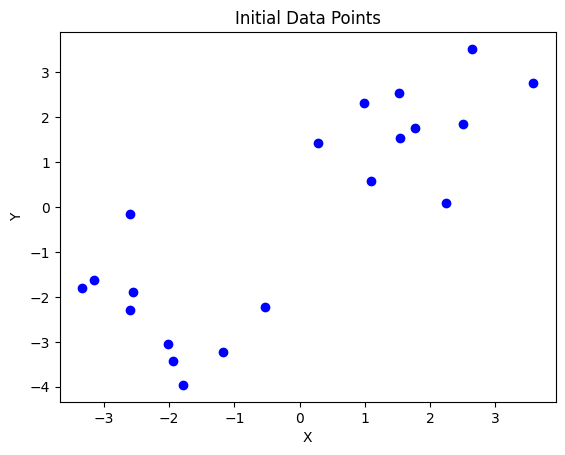

In [ ]:
#initial plotting
plt.scatter(points[:, 0], points[:, 1], c='blue', marker='o')
plt.title('Initial Data Points')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [4]:
# Initialize random centroids
centroids = points[np.random.choice(points.shape[0], 2, replace=False)]

In [ ]:
def plot_clusters(points, centroids, labels, title):
    plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='coolwarm', s=100)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='x')
    plt.title(title)
    plt.show()

def compute_wcss(points, centroids, labels):
    wcss = 0
    for i in range(centroids.shape[0]):
        wcss += np.sum((points[labels == i] - centroids[i]) ** 2)
    return wcss


In [7]:
#plot the Clusters using the helper functions
def kmeans_with_wcss(points, centroids, max_iters=10):
    wcss_values = []

    for i in range(max_iters):
        # Expectation step: assign points to the closest centroid
        distances = np.linalg.norm(points[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Plot clusters after expectation step
        plot_clusters(points, centroids, labels, f'Iteration {i + 1}: Expectation Step')

        # Maximization step: compute new centroids
        new_centroids = np.array([points[labels == j].mean(axis=0) for j in range(centroids.shape[0])])

        # Compute and store WCSS after each maximization step
        wcss = compute_wcss(points, new_centroids, labels)
        wcss_values.append(wcss)

        # Plot clusters after maximization step
        plot_clusters(points, new_centroids, labels, f'Iteration {i + 1}: Maximization Step - WCSS: {wcss:.2f}')

        # Check for convergence
        if np.all(centroids == new_centroids):
            print(f"Converged after {i + 1} iterations.")
            break

        centroids = new_centroids

    # Plot the WCSS values over iterations
    plt.plot(range(1, len(wcss_values) + 1), wcss_values, marker='o')
    plt.title('WCSS over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('WCSS')
    plt.show()


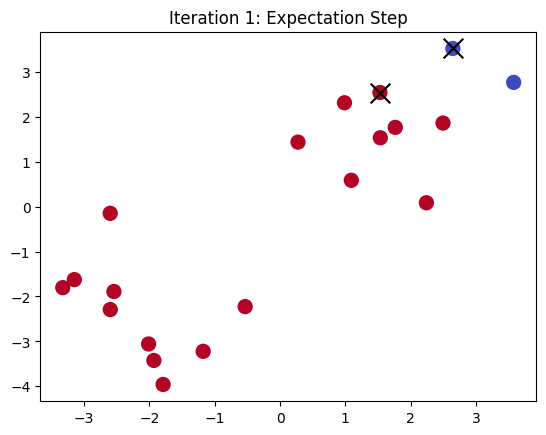

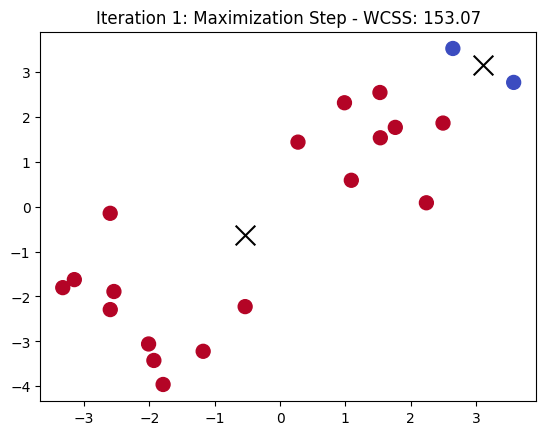

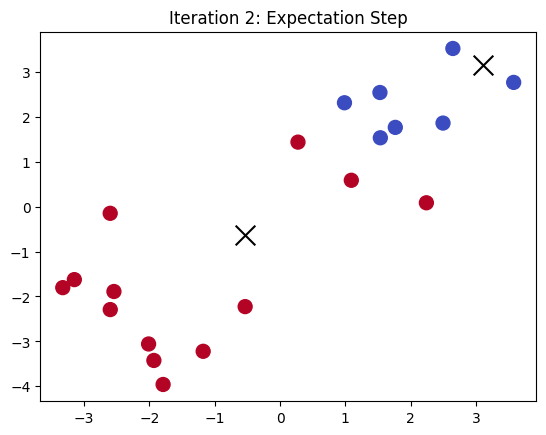

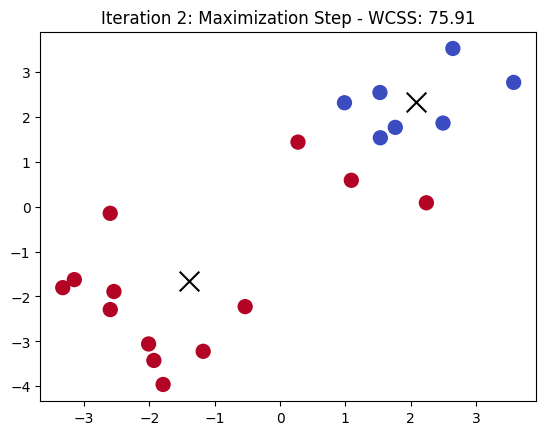

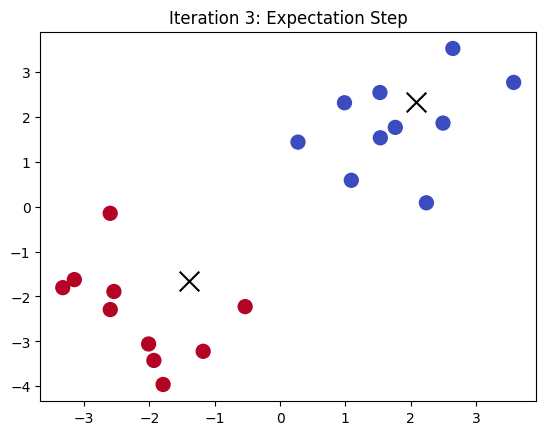

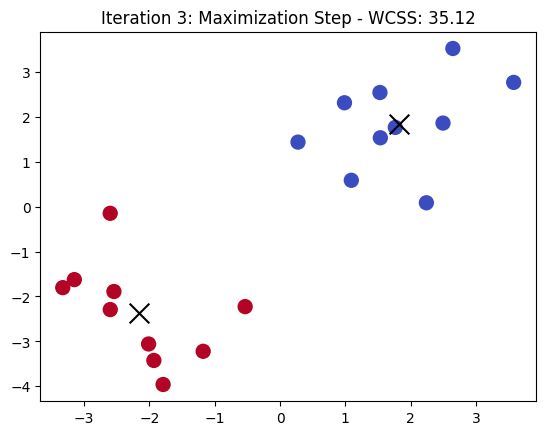

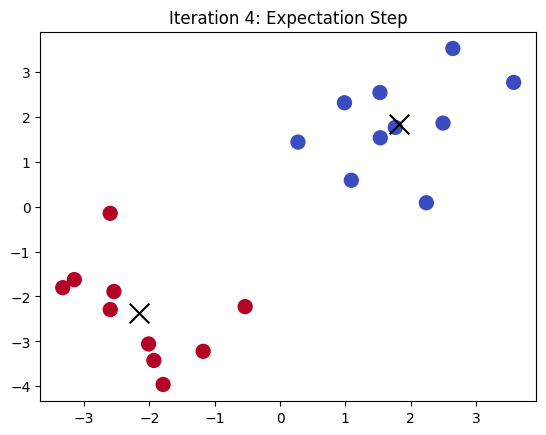

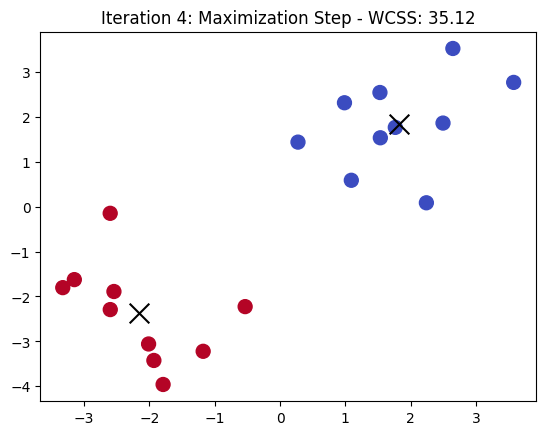

Converged after 4 iterations.


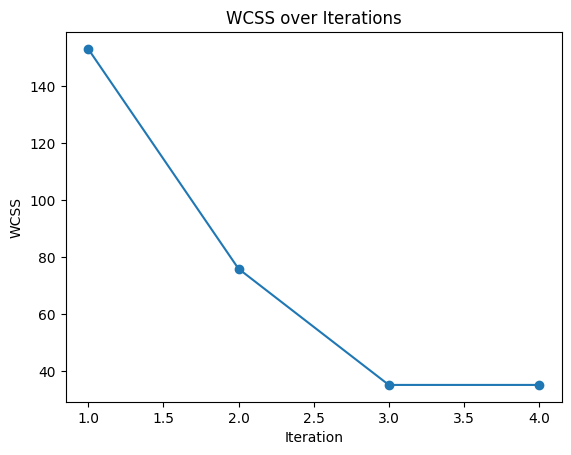

In [8]:
# Run K-Means algorithm with WCSS tracking
centroids = points[np.random.choice(points.shape[0], 2, replace=False)]
kmeans_with_wcss(points, centroids)